# Unit II: Descriptive Statistics & Exploratory Data Analysis (EDA)

This unit actively builds upon our previous Data Preprocessing layer. Here we compute formal metrics regarding **Central Tendency**, **Dispersion**, **Skewness**, and **Kurtosis**. We also analyze relationships via **Covariance/Correlation Matrices** and auto-generate the visualization suite deployed in the project's markdown documentation.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure the assets directory exists for dynamically saving plots
os.makedirs('../assets', exist_ok=True)

import warnings
warnings.filterwarnings('ignore')

### 1. Data Loading
We load the scaled dataset for machine interpretation, but we also load a lightly cleaned, unscaled version strictly to generate human-readable descriptive statistics and plots (so that means map to real values like `demand=150` instead of z-scores like `0.33`).

In [14]:
# Machine-ready dataset (Scaled, One-hot encoded)
df_scaled = pd.read_csv("../data/cleaned_food_delivery_data.csv")

# Human-readable dataset for EDA and descriptive stats
df = pd.read_csv("../data/Customer_data.csv")
df = df.dropna().drop_duplicates()
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df = df.rename(columns={'no._of_orders_placed': 'demand', 'no_of_orders_placed': 'demand', 'restaurnat_rating': 'restaurant_rating'})

# Clean up delivery time explicitly for descriptive measures
df = df[df['delivery_time'] != 'Delivery Time']
df['delivery_time'] = df['delivery_time'].astype(int)

### 2. Core Descriptive Statistics Table
Fulfilling the syllabus requirement: Central tendency (Mean, Median, Mode) and Dispersion (Standard Deviation, Variance, Range, IQR) alongside Shape parameters (Skewness, Kurtosis).

In [15]:
numeric_cols = ['age', 'family_size', 'restaurant_rating', 'delivery_rating', 'demand', 'delivery_time', 'order_value']

stats_df = pd.DataFrame()
for col in numeric_cols:
    stats_df[col] = [
        df[col].mean(),
        df[col].median(),
        df[col].mode()[0],
        df[col].std(),
        df[col].var(),
        df[col].max() - df[col].min(), # Range
        df[col].quantile(0.75) - df[col].quantile(0.25), # IQR
        df[col].skew(),
        df[col].kurtosis(),
        df[col].min(),
        df[col].max()
    ]
stats_df.index = ['Mean', 'Median', 'Mode', 'Std Dev', 'Variance', 'Range', 'IQR', 'Skewness', 'Kurtosis', 'Min', 'Max']

print("===== DESCRIPTIVE STATISTICS (UNSCALED) =====")
display(stats_df.round(3))

===== DESCRIPTIVE STATISTICS (UNSCALED) =====


,age,family_size,restaurant_rating,delivery_rating,demand,delivery_time,order_value
Mean,25.741,3.368,3.006,2.953,138.551,38.049,1.977
Median,25.000,3.000,3.000,3.000,138.500,39.000,2.000
Mode,23.000,3.000,3.000,4.000,49.000,17.000,1.000
Std Dev,4.314,1.505,1.391,1.413,67.431,16.495,0.831
Variance,18.613,2.266,1.936,1.996,4546.887,272.080,0.690
Range,17.000,5.000,4.000,4.000,234.000,65.000,2.000
IQR,5.000,3.000,2.000,2.000,118.500,29.000,2.000
Skewness,0.455,0.260,0.021,0.009,0.030,0.202,0.042
Kurtosis,-0.539,-0.935,-1.233,-1.315,-1.222,-1.053,-1.551
Min,18.000,1.000,1.000,1.000,23.000,9.000,1.000


### 3. Covariance & Correlation Summary
Addressing the syllabus requirement to document not just correlations, but the pure unstandardized Covariance array holding joint variability between variables.

In [16]:
print("===== COVARIANCE MATRIX =====")
display(df[numeric_cols].cov().round(3))

print("\n===== CORRELATION MATRIX =====")
display(df[numeric_cols].corr().round(3))

===== COVARIANCE MATRIX =====


,age,family_size,restaurant_rating,delivery_rating,demand,delivery_time,order_value
age,18.613,0.419,0.245,0.357,-8.745,-3.107,0.468
family_size,0.419,2.266,-0.037,0.096,-1.960,-1.453,0.025
restaurant_rating,0.245,-0.037,1.936,0.011,1.904,-0.470,-0.043
delivery_rating,0.357,0.096,0.011,1.996,2.162,-0.969,0.040
demand,-8.745,-1.960,1.904,2.162,4546.887,-5.889,1.485
delivery_time,-3.107,-1.453,-0.470,-0.969,-5.889,272.080,-0.193
order_value,0.468,0.025,-0.043,0.040,1.485,-0.193,0.690



===== CORRELATION MATRIX =====


,age,family_size,restaurant_rating,delivery_rating,demand,delivery_time,order_value
age,1.000,0.065,0.041,0.059,-0.030,-0.044,0.131
family_size,0.065,1.000,-0.018,0.045,-0.019,-0.059,0.020
restaurant_rating,0.041,-0.018,1.000,0.005,0.020,-0.020,-0.037
delivery_rating,0.059,0.045,0.005,1.000,0.023,-0.042,0.034
demand,-0.030,-0.019,0.020,0.023,1.000,-0.005,0.027
delivery_time,-0.044,-0.059,-0.020,-0.042,-0.005,1.000,-0.014
order_value,0.131,0.020,-0.037,0.034,0.027,-0.014,1.000


### 4. Auto-Updating EDA Plots (Overwriting `../assets/`)
We dynamically save structured plots targeting key project dimensions directly into the `/assets/` directory. By locking the filenames, future changes to the dataset will automatically trigger a visual cascade updating the project's README file seamlessly.

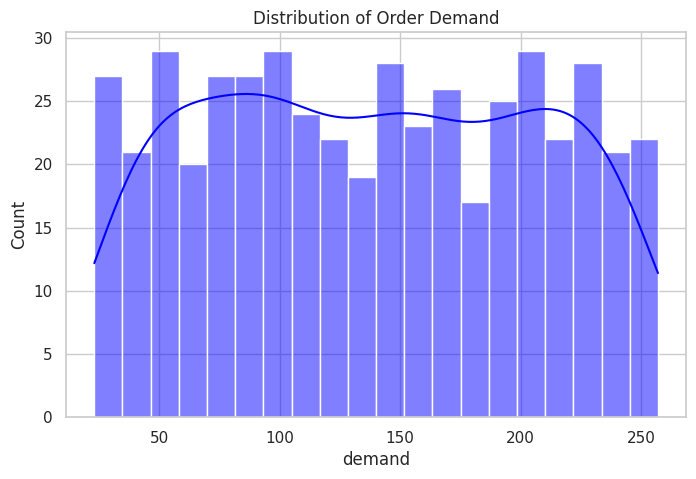

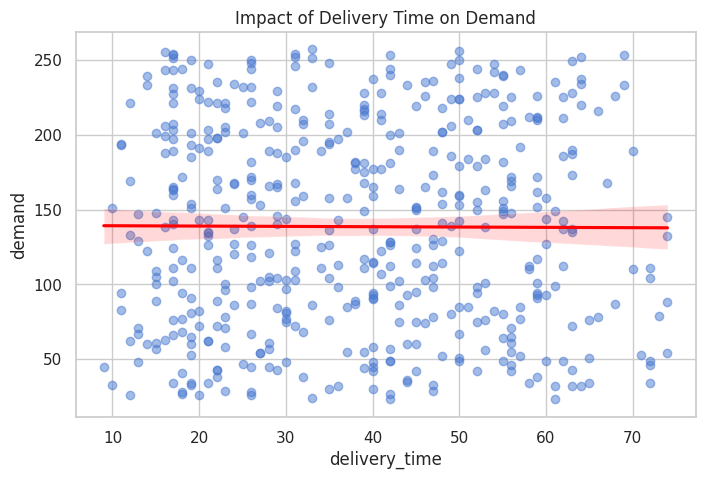

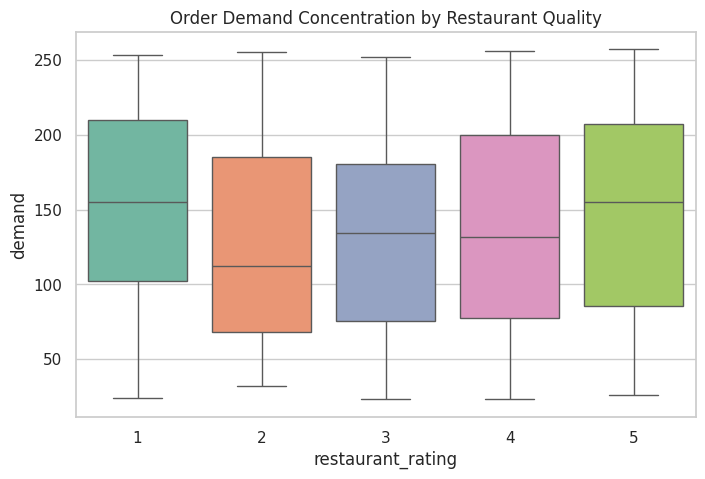

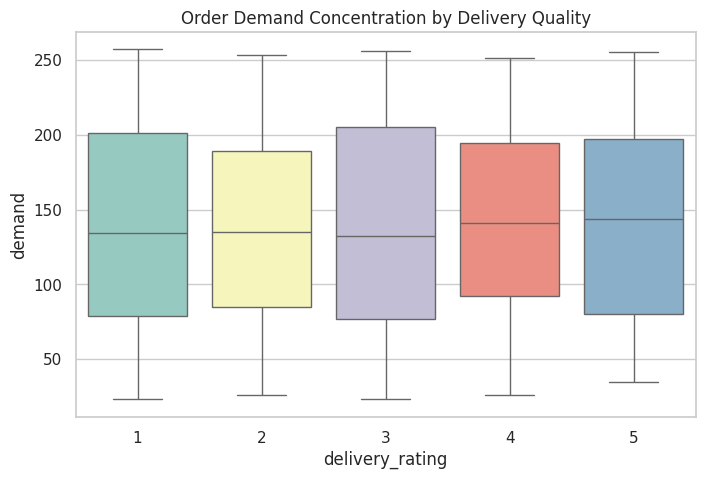

In [17]:
sns.set_theme(style="whitegrid", palette="muted")

# 1. Demand Histogram
plt.figure(figsize=(8, 5))
sns.histplot(df['demand'], kde=True, color='blue', bins=20)
plt.title("Distribution of Order Demand")
plt.savefig('../assets/demand_hist.png', bbox_inches='tight')
plt.show()

# 2. Regplot: Demand vs Delivery Time
plt.figure(figsize=(8, 5))
sns.regplot(x='delivery_time', y='demand', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title("Impact of Delivery Time on Demand")
plt.savefig('../assets/delivery_time_regplot.png', bbox_inches='tight')
plt.show()

# 3. Boxplot: Demand by Restaurant Rating
plt.figure(figsize=(8, 5))
sns.boxplot(x='restaurant_rating', y='demand', data=df, palette='Set2')
plt.title("Order Demand Concentration by Restaurant Quality")
plt.savefig('../assets/restaurant_rating_box.png', bbox_inches='tight')
plt.show()

# 4. Boxplot: Demand by Delivery Rating 
plt.figure(figsize=(8, 5))
sns.boxplot(x='delivery_rating', y='demand', data=df, palette='Set3')
plt.title("Order Demand Concentration by Delivery Quality")
plt.savefig('../assets/delivery_rating_box.png', bbox_inches='tight')
plt.show()

### 5. Final Advanced Analytics Visuals
We output the heatmap and categorical boxplots.

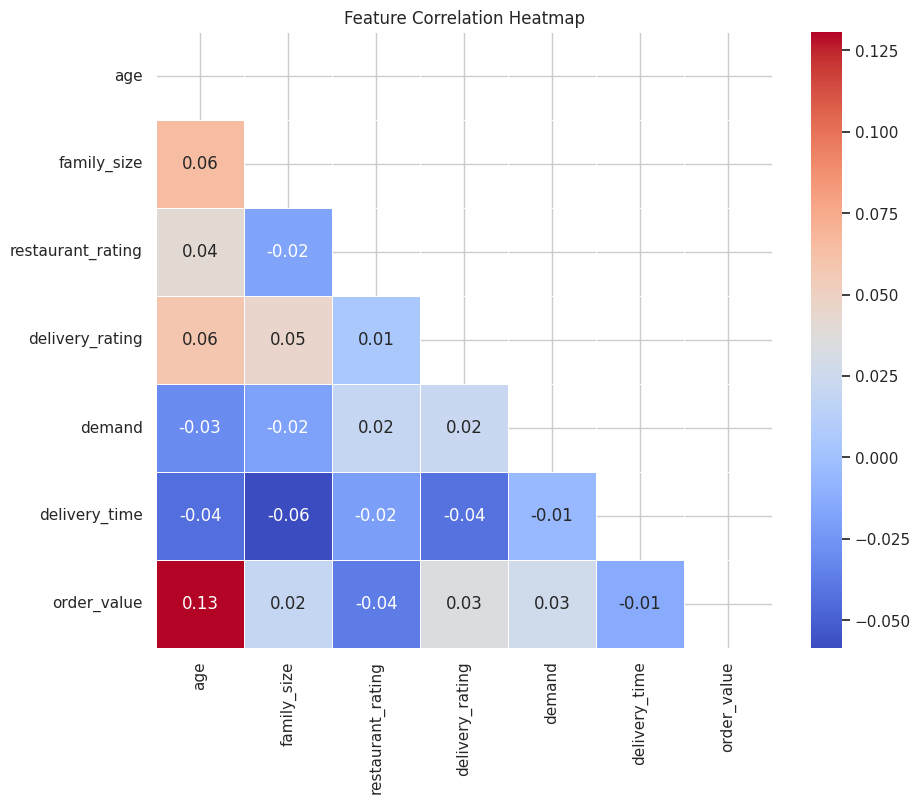

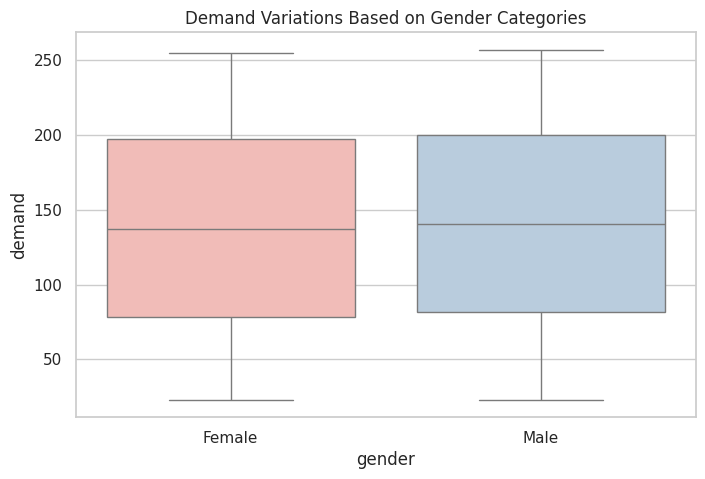

✓ Visualizations successfully rendered and saved to the /assets/ directory!


In [18]:
# 5. Correlation Heatmap
plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=.5)
plt.title("Feature Correlation Heatmap")
plt.savefig('../assets/heatmap.png', bbox_inches='tight')
plt.show()

# 6. Boxplot: Demand by Gender
plt.figure(figsize=(8, 5))
sns.boxplot(x='gender', y='demand', data=df, palette='Pastel1')
plt.title("Demand Variations Based on Gender Categories")
plt.savefig('../assets/gender_boxplot.png', bbox_inches='tight')
plt.show()

print("✓ Visualizations successfully rendered and saved to the /assets/ directory!")